# Early Warning Risiko Mahasiswa OULAD
## Evaluasi Model, Knowledge-Based System, dan Dashboard DVBI

**Judul:** Early Warning Risiko Dropout Mahasiswa pada Minggu Keempat Menggunakan Supervised Learning dan KnowledgeBased Risk Layer pada Open University Learning Analytics Dataset  
**Mata Kuliah:** Data Visualization and Business Intelligence  
**Kelompok:** 5  
**Program Studi:** S2 PJJ Informatika, Konsentrasi Big Data dan Predictive Analytics  
**Institusi:** Universitas Amikom Yogyakarta

| Nama | NIM |
|---|---|
| Muhammad Rizky Hajar | 24.55.2714 |
| Alwie Muflich | 24.55.2667 |
| Heri Santosa | 24.55.2676 |

### Ringkasan Penelitian

Penelitian ini membangun *early warning system* untuk mengenali mahasiswa yang berisiko memperoleh hasil akhir `Withdrawn` atau `Fail` sejak akhir minggu ke-4. Data yang digunakan adalah OULAD (*Open University Learning Analytics Dataset*), dengan informasi profil, registrasi, assessment, dan aktivitas pada VLE (*Virtual Learning Environment*). Informasi sampai hari ke-28 digunakan sebagai masukan agar peringatan dapat ditindaklanjuti.

Masalah ini berada pada ranah *predictive analytics*, yaitu penggunaan data untuk memperkirakan kondisi yang akan terjadi. Metode yang digunakan adalah *supervised binary classification*: model belajar dari data berlabel untuk membedakan `AtRisk` (`Withdrawn` atau `Fail`) dan `Successful` (`Pass` atau `Distinction`). Label hasil akhir tersebut menjadi dasar proses klasifikasi.

Tiga model pembanding, Logistic Regression, Random Forest, dan XGBoost, dievaluasi menggunakan group-based student split dan 5-fold cross-validation, yaitu evaluasi berulang pada lima pembagian training data dan validation data. Model final dipilih berdasarkan recall `AtRisk`, yaitu proporsi mahasiswa yang benar-benar berisiko dan berhasil dikenali, karena mahasiswa berisiko yang terlewat merupakan perhatian utama dalam early warning.

Keluaran penelitian meliputi evaluasi model, *knowledge-based risk layer*, dan dashboard. Knowledge layer adalah aturan yang menggabungkan prediksi model, probabilitas risiko, serta sinyal assessment dan VLE untuk menyusun prioritas `High`, `Medium`, atau `Low Risk`. Hasil ini berfungsi sebagai *decision support* atau alat bantu pengambilan keputusan; dosen dan pengelola akademik melakukan verifikasi sebelum intervensi.


### Alur Analitik Penelitian

```
Data hingga hari ke-28
        |
        v
Klasifikasi biner: Successful atau AtRisk
        |
        +--> prediksi kelas dan P(AtRisk)
        |
        v
Aturan perilaku awal: assessment dan aktivitas VLE
        |
        v
Prioritas intervensi: High, Medium, atau Low Risk
```

Model menghasilkan dua kelas: `Successful` dan `AtRisk`. Level `High Risk`, `Medium Risk`, dan `Low Risk` dibentuk setelah prediksi dengan menggabungkan hasil model dan sinyal perilaku awal. Level tersebut menyusun urutan tindak lanjut melalui aturan knowledge layer.

`P(AtRisk)` berarti probabilitas kelas `AtRisk` menurut model. Nilai ini membantu mengurutkan prioritas, sedangkan keputusan intervensi tetap mempertimbangkan sinyal perilaku dan verifikasi oleh pengelola akademik.

## 1. Konfigurasi Analisis

Analisis menggunakan library untuk pengolahan data, visualisasi, preprocessing, evaluasi, dan tiga algoritma klasifikasi. `RANDOM_STATE=42` menjaga data split tetap dapat direproduksi, sedangkan `CUTOFF_DAY=28` menetapkan observation horizon pada akhir minggu ke-4.

**Alasan cut-off:** cut-off adalah batas waktu data yang boleh digunakan model. Hari ke-28 merepresentasikan akhir minggu ke-4, yaitu fase awal yang masih memberi ruang bagi dosen atau tutor untuk melakukan intervensi. Pada titik ini, data assessment dan aktivitas VLE awal sudah mulai terbentuk sehingga dapat digunakan sebagai sinyal prediktif awal.

Parameter ini menjaga eksperimen dapat dijalankan kembali dengan horizon observasi yang sama.


In [1]:
# Library standar untuk file, download, ekstraksi zip, dan pengaturan warning.
import os, shutil, urllib.request, zipfile, warnings
from pathlib import Path
from collections import Counter

# Library utama untuk manipulasi data dan visualisasi.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Komponen scikit-learn dan XGBoost untuk preprocessing, model, split, dan evaluasi.
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Pengaturan tampilan agar output notebook lebih rapi saat dipresentasikan.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 100)

# Parameter eksperimen: seed reproduksibilitas dan batas early warning minggu ke-4.
RANDOM_STATE = 42
CUTOFF_DAY = 28
PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUNTIME_DIR = Path('/content') if Path('/content').is_dir() else PROJECT_DIR / 'tmp' / 'oulad_runtime'
DATA_DIR = RUNTIME_DIR / 'oulad'
print(f'Parameter eksperimen: random state {RANDOM_STATE}; horizon observasi {CUTOFF_DAY} hari')

Parameter eksperimen: random state 42; horizon observasi 28 hari


## 2. Akuisisi Data OULAD

OULAD (*Open University Learning Analytics Dataset*) adalah dataset terbuka berisi data pembelajaran mahasiswa dari Open University. Arsip data diperoleh dari UCI Machine Learning Repository, diekstrak, lalu diverifikasi melalui tujuh tabel sumber yang diperlukan.


In [2]:
# Lokasi dataset dan daftar file yang harus tersedia setelah ekstraksi.
DATA_URL = 'https://archive.ics.uci.edu/static/public/349/open+university+learning+analytics+dataset.zip'
ZIP_PATH = RUNTIME_DIR / 'anonymisedData.zip'
EXPECTED_FILES = {'assessments.csv', 'courses.csv', 'studentAssessment.csv',
                  'studentInfo.csv', 'studentRegistration.csv',
                  'studentVle.csv', 'vle.csv'}

# Cek isi folder data; download hanya dilakukan jika file belum lengkap.
DATA_DIR.mkdir(parents=True, exist_ok=True)
available = {p.name for p in DATA_DIR.glob('*.csv')}
if not EXPECTED_FILES.issubset(available):
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH) as archive:
        archive.extractall(DATA_DIR)

# Validasi akhir memastikan seluruh file CSV sumber sudah tersedia.
available = {p.name for p in DATA_DIR.glob('*.csv')}
missing = EXPECTED_FILES - available
assert not missing, f'File dataset tidak lengkap: {sorted(missing)}'
print('Tujuh tabel sumber dimuat:', ', '.join(sorted(EXPECTED_FILES)))

Tujuh tabel sumber dimuat: assessments.csv, courses.csv, studentAssessment.csv, studentInfo.csv, studentRegistration.csv, studentVle.csv, vle.csv


## 3. Struktur Dataset

Tabel sumber mencakup `studentInfo` untuk profil dan hasil akhir, `studentRegistration` untuk tanggal registrasi, `assessments` untuk konteks modul dan penilaian, serta tabel aktivitas VLE (*Virtual Learning Environment*), yaitu platform pembelajaran daring tempat aktivitas akses mahasiswa tercatat. Ringkasan berikut menunjukkan ukuran setiap tabel, diikuti preview sumber label dan data registrasi.


In [3]:
# Baca tabel sumber yang dipakai untuk profil, registrasi, assessment, dan aktivitas VLE.
student_info = pd.read_csv(DATA_DIR / 'studentInfo.csv')
registration = pd.read_csv(DATA_DIR / 'studentRegistration.csv')
assessments = pd.read_csv(DATA_DIR / 'assessments.csv')
student_assessment = pd.read_csv(DATA_DIR / 'studentAssessment.csv')
student_vle = pd.read_csv(DATA_DIR / 'studentVle.csv')

# Ringkas ukuran tiap tabel agar struktur data awal mudah diperiksa.
source_summary = pd.DataFrame({
    'tabel': ['studentInfo', 'studentRegistration', 'assessments', 'studentAssessment', 'studentVle'],
    'baris': [len(student_info), len(registration), len(assessments), len(student_assessment), len(student_vle)],
    'kolom': [student_info.shape[1], registration.shape[1], assessments.shape[1],
              student_assessment.shape[1], student_vle.shape[1]]
})
display(source_summary.style.format(thousands=','))

# Preview terpilih menunjukkan asal label hasil dan informasi registrasi.
print('Sumber label hasil akhir: studentInfo')
display(student_info[['id_student', 'code_module', 'code_presentation', 'final_result']].head(3))
print('Sumber informasi registrasi: studentRegistration')
display(registration[['id_student', 'code_module', 'code_presentation',
                      'date_registration', 'date_unregistration']].head(3))

,tabel,baris,kolom
0,studentInfo,"32,593",12
1,studentRegistration,"32,593",5
2,assessments,206,6
3,studentAssessment,"173,912",5
4,studentVle,"10,655,280",6


Sumber label hasil akhir: studentInfo


,id_student,code_module,code_presentation,final_result
0,11391,AAA,2013J,Pass
1,28400,AAA,2013J,Pass
2,30268,AAA,2013J,Withdrawn


Sumber informasi registrasi: studentRegistration


,id_student,code_module,code_presentation,date_registration,date_unregistration
0,11391,AAA,2013J,-159,?
1,28400,AAA,2013J,-53,?
2,30268,AAA,2013J,-92,12


## 4. Konstruksi Dataset Early Warning Minggu Ke-4

Dataset analisis dibentuk dari features yang tersedia hingga hari ke-28. Target `AtRisk` berasal dari hasil akhir, assessment difilter dengan `date_submitted <= 28`, dan aktivitas VLE difilter dengan `date <= 28`. *Target* adalah hasil yang diprediksi, sedangkan *feature* adalah informasi masukan model. Data diringkas per mahasiswa, modul, dan presentation untuk membentuk unit analisis *student-module-presentation*.

Data aktivitas OULAD memiliki informasi waktu berbasis hari relatif terhadap awal course. Notebook menggunakan data harian tersebut sebagai sumber, lalu merangkumnya menjadi aggregated features minggu ke-4 seperti total klik VLE, jumlah hari aktif, jumlah assessment, dan mean score assessment.

`final_result` membentuk label supervised learning. Model belajar dari data awal minggu ke-4 untuk memprediksi kelas akhir, sedangkan daftar prediktor berisi informasi yang tersedia sampai hari ke-28.

Mahasiswa dengan status akhir `Withdrawn` tetap menjadi bagian dari label `AtRisk` karena tujuan model adalah mengenali pola awal yang berkaitan dengan risiko tersebut. Interpretasi hasil berfokus pada sinyal yang tersedia sampai hari ke-28.

Jejak konstruksi berikut memperlihatkan baris assessment dan VLE setelah filter hari ke-28, aggregated features, serta dataset analisis yang terbentuk.


In [4]:
KEYS = ['code_module', 'code_presentation', 'id_student']

# Target biner berasal dari hasil akhir; ini label supervised learning, bukan fitur prediksi.
# Fitur prediktor tetap dibatasi pada data yang tersedia sampai hari ke-28.
base = student_info.copy()
base['risk_label'] = np.where(base['final_result'].isin(['Withdrawn', 'Fail']), 'AtRisk', 'Successful')

# Fitur registrasi yang tersedia sebelum/awal perkuliahan; unregistration sengaja dikeluarkan.
# date_unregistration bersifat post-hoc sehingga berisiko leakage untuk early warning minggu ke-4.
reg_features = registration[KEYS + ['date_registration']].copy()

# Hubungkan submission ke konteks module-presentation, lalu batasi sampai hari ke-28.
student_assessment['date_submitted'] = pd.to_numeric(student_assessment['date_submitted'], errors='coerce')
student_assessment['score'] = pd.to_numeric(student_assessment['score'], errors='coerce')
assessment_early = student_assessment.merge(
    assessments[['id_assessment', 'code_module', 'code_presentation']],
    on='id_assessment', how='left'
)
assessment_early = assessment_early[assessment_early['date_submitted'] <= CUTOFF_DAY]
assessment_features = (assessment_early.groupby(KEYS)
    .agg(assessment_count=('id_assessment', 'count'),
         assessment_score_mean=('score', 'mean'),
         assessment_score_max=('score', 'max'),
         assessment_score_min=('score', 'min'))
    .reset_index())

# Aktivitas VLE juga dibatasi sampai hari ke-28.
student_vle['date'] = pd.to_numeric(student_vle['date'], errors='coerce')
student_vle['sum_click'] = pd.to_numeric(student_vle['sum_click'], errors='coerce').fillna(0)
vle_early = student_vle[student_vle['date'] <= CUTOFF_DAY].copy()
vle_features = (vle_early.groupby(KEYS)
    .agg(vle_total_clicks=('sum_click', 'sum'),
         vle_active_days=('date', 'nunique'),
         vle_site_count=('id_site', 'nunique'),
         vle_last_activity_day=('date', 'max'))
    .reset_index())

dataset = (base.merge(reg_features, on=KEYS, how='left')
               .merge(assessment_features, on=KEYS, how='left')
               .merge(vle_features, on=KEYS, how='left'))

behavior_cols = ['assessment_count', 'assessment_score_mean', 'assessment_score_max',
                 'assessment_score_min', 'vle_total_clicks', 'vle_active_days',
                 'vle_site_count', 'vle_last_activity_day']
dataset[behavior_cols] = dataset[behavior_cols].fillna(0)

# Jejak observasi hingga hari ke-28 dan fitur hasil agregasi.
print('Assessment yang tersedia hingga hari ke-28')
display(assessment_early[['id_student', 'code_module', 'code_presentation',
                          'date_submitted', 'score']].head(3))
print('Assessment features per student-module-presentation')
assessment_preview = assessment_features.rename(columns={
    'code_module': 'Modul', 'code_presentation': 'Presentasi', 'id_student': 'Mahasiswa',
    'assessment_count': 'Assessment count', 'assessment_score_mean': 'Mean score',
    'assessment_score_max': 'Maximum score', 'assessment_score_min': 'Minimum score'
})
display(assessment_preview.head(3))
print('Aktivitas VLE yang tersedia hingga hari ke-28')
display(vle_early[['id_student', 'date', 'id_site', 'sum_click']].head(3))
print('VLE features per student-module-presentation')
vle_preview = vle_features.rename(columns={
    'code_module': 'Modul', 'code_presentation': 'Presentasi', 'id_student': 'Mahasiswa',
    'vle_total_clicks': 'Total VLE clicks', 'vle_active_days': 'Active VLE days',
    'vle_site_count': 'VLE site count', 'vle_last_activity_day': 'Last activity day'
})
display(vle_preview.head(3))

print(f'Unit analisis: {len(dataset):,} student-module-presentation')
print(f'Mahasiswa unik: {dataset.id_student.nunique():,}')
analysis_columns = (KEYS + ['final_result', 'risk_label', 'date_registration',
                    'assessment_count', 'assessment_score_mean',
                    'vle_total_clicks', 'vle_active_days'])
print('Analysis dataset setelah merging dan aggregation')
analysis_preview = dataset[analysis_columns].rename(columns={
    'code_module': 'Modul', 'code_presentation': 'Presentasi', 'id_student': 'Mahasiswa',
    'final_result': 'Final result', 'risk_label': 'Risk label',
    'date_registration': 'Registration day', 'assessment_count': 'Assessment count',
    'assessment_score_mean': 'Mean score', 'vle_total_clicks': 'Total VLE clicks',
    'vle_active_days': 'Active VLE days'
})
display(analysis_preview.head(5))

Assessment yang tersedia hingga hari ke-28


,id_student,code_module,code_presentation,date_submitted,score
0,11391,AAA,2013J,18,78.0
1,28400,AAA,2013J,22,70.0
2,31604,AAA,2013J,17,72.0


Assessment features per student-module-presentation


,Modul,Presentasi,Mahasiswa,Assessment count,Mean score,Maximum score,Minimum score
0,AAA,2013J,11391,1,78.0,78.0,78.0
1,AAA,2013J,28400,1,70.0,70.0,70.0
2,AAA,2013J,31604,1,72.0,72.0,72.0


Aktivitas VLE yang tersedia hingga hari ke-28


,id_student,date,id_site,sum_click
0,28400,-10,546652,4
1,28400,-10,546652,1
2,28400,-10,546652,1


VLE features per student-module-presentation


,Modul,Presentasi,Mahasiswa,Total VLE clicks,Active VLE days,VLE site count,Last activity day
0,AAA,2013J,11391,401,8,24,18
1,AAA,2013J,28400,618,19,34,28
2,AAA,2013J,30268,281,12,22,12


Unit analisis: 32,593 student-module-presentation
Mahasiswa unik: 28,785
Analysis dataset setelah merging dan aggregation


,Modul,Presentasi,Mahasiswa,Final result,Risk label,Registration day,Assessment count,Mean score,Total VLE clicks,Active VLE days
0,AAA,2013J,11391,Pass,Successful,-159,1.0,78.0,401.0,8.0
1,AAA,2013J,28400,Pass,Successful,-53,1.0,70.0,618.0,19.0
2,AAA,2013J,30268,Withdrawn,AtRisk,-92,0.0,0.0,281.0,12.0
3,AAA,2013J,31604,Pass,Successful,-52,1.0,72.0,494.0,22.0
4,AAA,2013J,32885,Pass,Successful,-176,1.0,69.0,567.0,24.0


## 5. Prediction Horizon Validation

*Prediction horizon* menetapkan informasi yang tersedia saat prediksi dibuat. Pada penelitian ini, seluruh predictors dibentuk dari observasi hingga hari ke-28. Validasi ini menjaga *data leakage*, yaitu masuknya informasi masa depan ke dalam proses prediksi. Daftar predictors mencakup data demografis, registrasi awal, assessment awal, dan aktivitas VLE awal.

**Tipe data yang digunakan:**

| Jenis data | Contoh kolom | Peran dalam notebook |
|---|---|---|
| Categorical features | `gender`, `region`, `imd_band`, `code_module` | Features yang diproses dengan one-hot encoding, yaitu mengubah setiap kategori menjadi penanda 0/1 |
| Numerical features | `studied_credits`, `assessment_count`, `vle_total_clicks` | Features yang diimputasi, yaitu diisi bila terdapat missing values, lalu distandardisasi agar skalanya sebanding |
| Temporal | `date_submitted`, `date`, `date_registration` | Dasar cut-off early warning sampai hari ke-28 |
| Target label | `risk_label` | Output klasifikasi biner |
| Identitas grouping | `id_student` | Grup untuk train-test split dan cross-validation, yaitu evaluasi berulang pada beberapa pembagian data |
| Kolom referensi hasil akhir | `final_result` | Sumber pembentukan label supervised learning |
| Informasi setelah kejadian | `date_unregistration` | Dikeluarkan dari daftar prediktor untuk menjaga informasi prediksi tetap tersedia pada minggu ke-4 |

Daftar features berikut mendefinisikan *feature matrix* sebagai input model.


In [5]:
# Pisahkan fitur kategorikal dan numerik untuk preprocessing yang berbeda.
CATEGORICAL_COLS = ['gender', 'region', 'highest_education', 'imd_band',
                    'age_band', 'disability', 'code_module', 'code_presentation']
NUMERIC_COLS = ['num_of_prev_attempts', 'studied_credits', 'date_registration',
                'assessment_count', 'assessment_score_mean', 'assessment_score_max',
                'assessment_score_min', 'vle_total_clicks', 'vle_active_days',
                'vle_site_count', 'vle_last_activity_day']
FEATURE_COLS = CATEGORICAL_COLS + NUMERIC_COLS
# Kolom berikut tidak boleh menjadi prediktor karena berisi target atau informasi post-hoc.
FORBIDDEN = {'final_result', 'risk_label', 'date_unregistration', 'has_unregistration'}

# Validasi anti-leakage: fitur model harus bebas dari target dan data setelah hari ke-28.
assert not FORBIDDEN.intersection(FEATURE_COLS)
assert vle_early['date'].max() <= CUTOFF_DAY
assert assessment_early['date_submitted'].max() <= CUTOFF_DAY
print('Prediction horizon: features dibentuk dari observasi hingga hari ke-28.')
print('Categorical features:', CATEGORICAL_COLS)
print('Numerical features:', NUMERIC_COLS)

Prediction horizon: features dibentuk dari observasi hingga hari ke-28.
Categorical features: ['gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability', 'code_module', 'code_presentation']
Numerical features: ['num_of_prev_attempts', 'studied_credits', 'date_registration', 'assessment_count', 'assessment_score_mean', 'assessment_score_max', 'assessment_score_min', 'vle_total_clicks', 'vle_active_days', 'vle_site_count', 'vle_last_activity_day']


## 6. Eksplorasi Data

*Exploratory Data Analysis* (EDA) memeriksa distribusi, kelengkapan, dan pola awal data sebelum pemodelan. Visualisasi berikut membandingkan distribusi target, missing values, serta median assessment dan aktivitas VLE pada kelas `AtRisk` dan `Successful`.


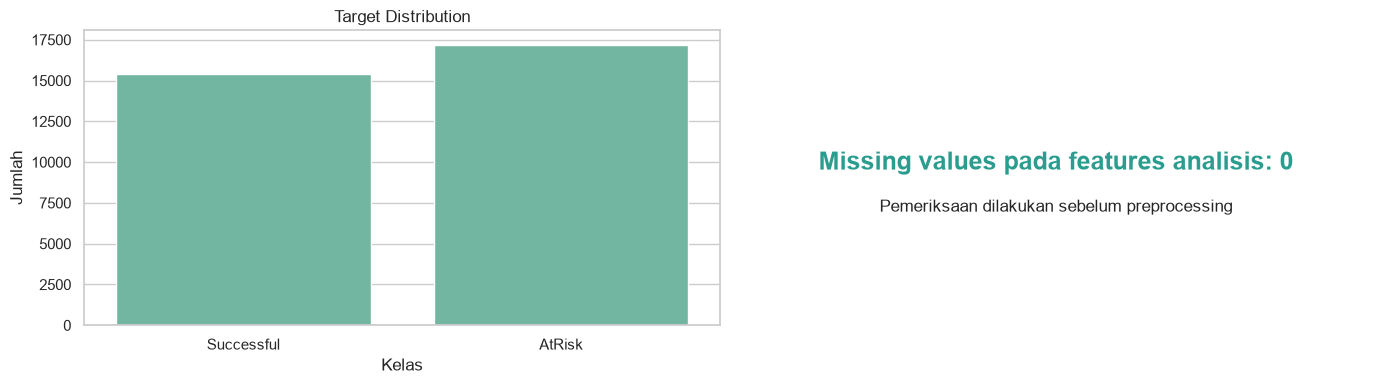

,assessment_count,assessment_score_mean,vle_total_clicks,vle_active_days
risk_label,,,,
AtRisk,1.0,0.0,92.0,7.0
Successful,1.0,76.0,298.0,16.0


risk_label
AtRisk        17208
Successful    15385
Name: count, dtype: int64


In [6]:
# Hitung missing value, distribusi target, dan median perilaku awal per kelas.
missing_summary = dataset[FEATURE_COLS].isna().sum().sort_values(ascending=False)
class_counts = dataset['risk_label'].value_counts()
behavior_by_class = dataset.groupby('risk_label')[
    ['assessment_count', 'assessment_score_mean', 'vle_total_clicks', 'vle_active_days']
].median().round(2)

# Tampilkan distribusi kelas dan kondisi missing value sebagai ringkasan EDA awal.
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=dataset, x='risk_label', order=['Successful', 'AtRisk'], ax=axes[0])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Kelas'); axes[0].set_ylabel('Jumlah')
missing_nonzero = missing_summary[missing_summary > 0]
if missing_nonzero.empty:
    axes[1].text(0.5, 0.55, 'Missing values pada features analisis: 0', ha='center', va='center',
                 fontsize=18, fontweight='bold', color='#2A9D8F')
    axes[1].text(0.5, 0.40, 'Pemeriksaan dilakukan sebelum preprocessing', ha='center', va='center')
    axes[1].set_axis_off()
else:
    missing_nonzero.plot(kind='bar', ax=axes[1], color='#E9C46A')
    axes[1].set_title('Missing Values by Feature')
    axes[1].set_xlabel('Fitur'); axes[1].set_ylabel('Jumlah')
plt.tight_layout(); plt.show()
# Tabel median membantu membandingkan perilaku minggu ke-4 antara kelas risiko.
display(behavior_by_class)
print(class_counts)

## 7. Data Split Design

*Hold-out test* adalah bagian data yang disisihkan sejak awal untuk mengukur kemampuan model pada data baru. *Data split* membagi data menjadi 80% train-validation dan 20% test menggunakan `id_student` sebagai grup melalui `GroupShuffleSplit`. Seluruh baris dari mahasiswa yang sama berada pada satu bagian data.

Train-validation dievaluasi menggunakan `GroupKFold`. *Fold* adalah satu bagian dari pembagian data dan bergantian menjadi validation, yaitu data untuk memeriksa model saat pelatihan. Ukuran split dan overlap mahasiswa diringkas pada output berikut.


### Skema evaluasi dan pemisahan data

```
Seluruh student-module-presentation
                 |  GroupShuffleSplit berdasarkan id_student
        +--------+--------+
        |                 |
80% train-validation   20% hold-out test
        |                 |
   GroupKFold 5-fold     Evaluasi final sekali
        |
Pilih model dari rerata recall AtRisk, lalu F1 sebagai tie-breaker
```

`id_student` digunakan sebagai grup sehingga setiap mahasiswa berada pada satu bagian data dan overlap bernilai nol. Lima fold digunakan pada bagian train-validation untuk memilih model. Hold-out test digunakan setelah model terpilih untuk mengukur generalisasi pada data baru.

In [7]:
# Pastikan seluruh fitur numerik siap diproses oleh pipeline model.
for column in NUMERIC_COLS:
    dataset[column] = pd.to_numeric(dataset[column], errors='coerce')

# Bentuk matriks fitur, target biner, dan grup mahasiswa untuk split berbasis id_student.
# Karena unit analisis adalah student-module-presentation, satu mahasiswa bisa muncul lebih dari sekali.
X = dataset[FEATURE_COLS].copy()
y = dataset['risk_label'].map({'Successful': 0, 'AtRisk': 1})
groups = dataset['id_student']
print('Feature matrix: tiga student-module-presentation pertama')
display(X.head(3).T.rename(columns={0: 'Sampel 1', 1: 'Sampel 2', 2: 'Sampel 3'}))

# Split 80:20 berbasis mahasiswa agar id_student yang sama tidak muncul di train dan test.
# Validation set statis tidak dibuat karena train-validation akan dievaluasi dengan GroupKFold.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()

# Cek overlap mahasiswa sebagai validasi bahwa split berbasis grup berhasil.
train_students = set(groups.iloc[train_idx])
test_students = set(groups.iloc[test_idx])
overlap = train_students.intersection(test_students)
assert len(overlap) == 0
print(f'Train-validation: {len(X_train):,} baris | Test: {len(X_test):,} baris')
print(f'Overlap mahasiswa: {len(overlap)}')
print('Distribusi train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Distribusi test :', y_test.value_counts(normalize=True).round(3).to_dict())

Feature matrix: tiga student-module-presentation pertama


,Sampel 1,Sampel 2,Sampel 3
gender,M,F,F
region,East Anglian Region,Scotland,North Western Region
highest_education,HE Qualification,HE Qualification,A Level or Equivalent
imd_band,90-100%,20-30%,30-40%
age_band,55<=,35-55,35-55
disability,N,N,Y
code_module,AAA,AAA,AAA
code_presentation,2013J,2013J,2013J
num_of_prev_attempts,0,0,0
studied_credits,240,60,60


Train-validation: 26,122 baris | Test: 6,471 baris
Overlap mahasiswa: 0
Distribusi train: {1: 0.529, 0: 0.471}
Distribusi test : {1: 0.525, 0: 0.475}


## 8. Pipeline Preprocessing dan Model

*Preprocessing* menyiapkan format dan nilai data untuk pemodelan. Numerical features diimputasi dengan median dan distandardisasi; categorical features diimputasi lalu diubah dengan one-hot encoding menjadi representasi 0/1. Seluruh transformasi berada di dalam pipeline sehingga parameter preprocessing dipelajari dari training data pada setiap fold.

Logistic Regression, Random Forest, dan XGBoost digunakan sebagai baseline, yaitu pembanding awal dengan konfigurasi yang konsisten. Hyperparameter, yaitu pengaturan model yang ditentukan sebelum pelatihan, dibuat tetap selama evaluasi agar perbandingan antar model mudah dibaca; tuning lanjutan dapat dilakukan setelah baseline terbaik ditentukan.

Tiga model pembanding yang digunakan adalah Logistic Regression, Random Forest, dan XGBoost.


### Ringkasan preprocessing

| Komponen | Perlakuan | Tujuan |
|---|---|---|
| Missing values pada numerical features | Median imputation | Menjaga baris tetap dapat diproses tanpa dipengaruhi nilai ekstrem. |
| Missing values pada categorical features | Most-frequent imputation | Menyediakan nilai yang konsisten sebelum encoding. |
| Categorical features | One-hot encoding | Mengubah kategori menjadi representasi numerik untuk model. |
| Numerical features | Standardization | Menyamakan skala untuk model yang sensitif terhadap besaran feature. |
| Class imbalance | `class_weight` atau `scale_pos_weight` | Memberi perhatian lebih besar pada kelas `AtRisk` tanpa membuat data sintetis. |

Seluruh imputasi, encoding, dan standardisasi berada di dalam pipeline. Pada setiap fold, parameter preprocessing dipelajari dari training data fold tersebut. Class imbalance ditangani dengan `class_weight` atau `scale_pos_weight`, sementara distribusi kelas dan seluruh metrik ditampilkan agar trade-off prediksi dapat dibaca secara terbuka.

In [8]:
# Numerical features diimputasi lalu distandardisasi.
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Categorical features diimputasi lalu diubah menjadi one-hot encoding.
categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
# ColumnTransformer menerapkan pipeline sesuai tipe fitur.
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipe, NUMERIC_COLS),
    ('categorical', categorical_pipe, CATEGORICAL_COLS)
])

# Bobot kelas membantu model memberi perhatian pada kelas AtRisk.
negative, positive = np.bincount(y_train)
scale_pos_weight = negative / positive
# Tiga model dibandingkan dengan konfigurasi yang konsisten.
models = {
    'Logistic Regression': LogisticRegression(max_iter=1500, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=250, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.08,
                             subsample=0.9, colsample_bytree=0.9,
                             scale_pos_weight=scale_pos_weight, eval_metric='logloss',
                             random_state=RANDOM_STATE, n_jobs=-1)
}
# Gabungkan preprocessing dan model agar transformasi hanya belajar dari data train.
pipelines = {name: Pipeline([('preprocess', clone(preprocessor)), ('model', model)])
             for name, model in models.items()}
print('Model pembanding:', ', '.join(pipelines))

Model pembanding: Logistic Regression, Random Forest, XGBoost


## 9. Model Selection with Cross-Validation

Cross-validation mengevaluasi model secara berulang pada beberapa pembagian train dan validation. Tiga model dievaluasi dengan lima fold berbasis kelompok mahasiswa. Recall `AtRisk` menjadi metrik seleksi utama; F1 digunakan sebagai tie-breaker bila recall sama.

**Alasan metrik:** recall `AtRisk` diprioritaskan karena konteks early warning berfokus menangkap sebanyak mungkin mahasiswa berisiko. Precision, yaitu proporsi prediksi `AtRisk` yang benar, menunjukkan kualitas alarm. False positive menggambarkan alarm `AtRisk` pada mahasiswa `Successful` dan membantu membaca beban intervensi. Accuracy menunjukkan proporsi seluruh prediksi yang benar, sedangkan ROC-AUC menunjukkan kemampuan model membedakan dua kelas pada berbagai threshold.

**Alasan 5-fold:** lima fold memberi keseimbangan antara estimasi performa yang stabil dan biaya komputasi yang wajar untuk tiga model pembanding. Karena split menggunakan `GroupKFold`, prioritas evaluasi adalah menjaga mahasiswa yang sama berada dalam grup fold yang konsisten.

`GroupKFold` memprioritaskan pemisahan berdasarkan mahasiswa. Konsistensi performa antar fold dibaca melalui mean, yaitu rata-rata, dan standard deviation, yaitu ukuran variasi hasil antar fold. Standard deviation yang kecil menunjukkan hasil model relatif stabil pada beberapa pembagian train-validation.

Tabel berikut menampilkan mean dan standard deviation untuk accuracy, precision, recall, F1, dan ROC-AUC pada lima fold.


In [9]:
# Fungsi ini menyatukan metrik yang dipakai berulang pada CV dan hold-out test.
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_atrisk': precision_score(y_true, y_pred, zero_division=0),
        'recall_atrisk': recall_score(y_true, y_pred, zero_division=0),
        'f1_atrisk': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob)
    }

# GroupKFold menjaga mahasiswa yang sama tetap berada dalam fold yang sama.
# Setiap fold bergantian menjadi validation, sehingga tidak perlu validation split statis.
gkf = GroupKFold(n_splits=5)
cv_rows = []
for model_name, pipeline in pipelines.items():
    for fold, (fit_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups_train), start=1):
        fold_model = clone(pipeline)
        fold_model.fit(X_train.iloc[fit_idx], y_train.iloc[fit_idx])
        pred = fold_model.predict(X_train.iloc[val_idx])
        prob = fold_model.predict_proba(X_train.iloc[val_idx])[:, 1]
        cv_rows.append({'model': model_name, 'fold': fold,
                        **calculate_metrics(y_train.iloc[val_idx], pred, prob)})

# Ringkas hasil tiap fold menjadi rata-rata dan standar deviasi per model.
cv_detail = pd.DataFrame(cv_rows)
cv_summary = cv_detail.groupby('model').agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', 'std'),
    precision_mean=('precision_atrisk', 'mean'), precision_std=('precision_atrisk', 'std'),
    recall_mean=('recall_atrisk', 'mean'), recall_std=('recall_atrisk', 'std'),
    f1_mean=('f1_atrisk', 'mean'), f1_std=('f1_atrisk', 'std'),
    roc_auc_mean=('roc_auc', 'mean'), roc_auc_std=('roc_auc', 'std')
).sort_values(['recall_mean', 'f1_mean'], ascending=False)
display(cv_summary.style.format('{:.4f}').highlight_max(subset=['recall_mean', 'f1_mean'], color='#B7E4C7'))

,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
model,,,,,,,,,,
Random Forest,0.7524,0.0013,0.7989,0.0136,0.7107,0.0085,0.7521,0.0030,0.8362,0.0023
XGBoost,0.7584,0.0024,0.8215,0.0096,0.6938,0.0029,0.7522,0.0039,0.8440,0.0019
Logistic Regression,0.7496,0.0039,0.8090,0.0059,0.6889,0.0064,0.7442,0.0059,0.8330,0.0027


## 10. Evaluasi Generalisasi pada Hold-Out Test

Generalisasi adalah kemampuan model mempertahankan performa pada data di luar proses pelatihan. Model dipilih dari hasil cross-validation berdasarkan recall dan F1 `AtRisk`, kemudian dilatih pada seluruh train-validation. Hold-out test memberikan evaluasi generalisasi akhir dan perbandingan model.

Peringkat `cv_summary` pada lima fold train-validation menentukan model final. Hold-out test kemudian memberikan evaluasi generalisasi akhir. Random Forest dipilih ketika memberikan recall `AtRisk` tertinggi, sesuai tujuan utama early warning.

Tabel metrik dan classification report berikut merangkum performa model final pada hold-out test.


In [10]:
# Latih ulang setiap model pada seluruh train-validation, lalu prediksi hold-out test.
fitted_models, test_predictions, test_probabilities, test_rows = {}, {}, {}, []
for model_name, pipeline in pipelines.items():
    fitted = clone(pipeline).fit(X_train, y_train)
    pred = fitted.predict(X_test)
    prob = fitted.predict_proba(X_test)[:, 1]
    fitted_models[model_name] = fitted
    test_predictions[model_name] = pred
    test_probabilities[model_name] = prob
    test_rows.append({'model': model_name, **calculate_metrics(y_test, pred, prob)})

# Urutkan hasil test berdasarkan recall AtRisk dan F1.
test_results = pd.DataFrame(test_rows).set_index('model').sort_values(
    ['recall_atrisk', 'f1_atrisk'], ascending=False)
# Model terbaik mengikuti peringkat cross-validation agar pemilihan tidak memakai test set.
# Test set hanya menjadi pelaporan generalisasi akhir, bukan dasar tuning atau seleksi model.
best_model_name = cv_summary.index[0]
best_model = fitted_models[best_model_name]
best_pred = test_predictions[best_model_name]
best_prob = test_probabilities[best_model_name]

# Tampilkan tabel metrik dan classification report untuk model terbaik.
display(test_results.style.format('{:.4f}').highlight_max(subset=['recall_atrisk', 'f1_atrisk'], color='#B7E4C7'))
print(f'Model terpilih berdasarkan cross-validation: {best_model_name}')
print(classification_report(y_test, best_pred, target_names=['Successful', 'AtRisk']))

,accuracy,precision_atrisk,recall_atrisk,f1_atrisk,roc_auc
model,,,,,
Random Forest,0.7594,0.8007,0.7213,0.7589,0.8396
XGBoost,0.7611,0.8154,0.7045,0.7559,0.8443
Logistic Regression,0.7487,0.8034,0.6904,0.7426,0.8311


Model terpilih berdasarkan cross-validation: Random Forest
              precision    recall  f1-score   support

  Successful       0.72      0.80      0.76      3073
      AtRisk       0.80      0.72      0.76      3398

    accuracy                           0.76      6471
   macro avg       0.76      0.76      0.76      6471
weighted avg       0.76      0.76      0.76      6471



### Benchmark angka dengan penelitian sebelumnya

Bagian ini menyandingkan hasil model penelitian dengan paper yang menggunakan Open University Learning Analytics Dataset (OULAD). Benchmark mencakup model, target, dan horizon pengamatan yang dilaporkan pada setiap paper. Metrik kosong menunjukkan bahwa paper tersebut tidak melaporkan metrik yang sama pada skenario terkait.

Seluruh paper pada tabel menggunakan OULAD. Perbedaan target, horizon prediksi, desain split, penyeimbangan kelas, dan model menjelaskan konteks setiap angka. Hasil penelitian ini menggunakan cut-off hari ke-28 dan group split berdasarkan `id_student`. Tanda `-` menunjukkan metrik yang tidak dilaporkan pada skenario terkait.



,Sumber,Skenario,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Shou et al. (2024),"OULAD, 20% course, Pass/Distinction vs Fail/Withdrawn",MTAPSP (daily),0.9179,-,-,0.9180,-
1,Jawad et al. (2022),"OULAD, 260 hari + SMOTE",Random Forest,0.8920,-,-,-,0.9600
2,Balabied & Eid (2023),"OULAD, klasifikasi biner",Random Forest,0.9000,0.9000,0.9000,0.9000,-
3,Ujkani et al. (2024),"OULAD, Fail + Withdrawn sebagai at-risk",Custom Neural Network,0.9300,0.9500,0.9700,0.9600,-
4,Alnasyan et al. (2025),"OULAD, Pass + Distinction vs Fail + Withdrawn",KANFormer,0.9459,0.9495,0.9482,0.9481,0.9835
5,Notebook ini,OULAD minggu ke-4,Random Forest,0.7594,0.8007,0.7213,0.7589,0.8396


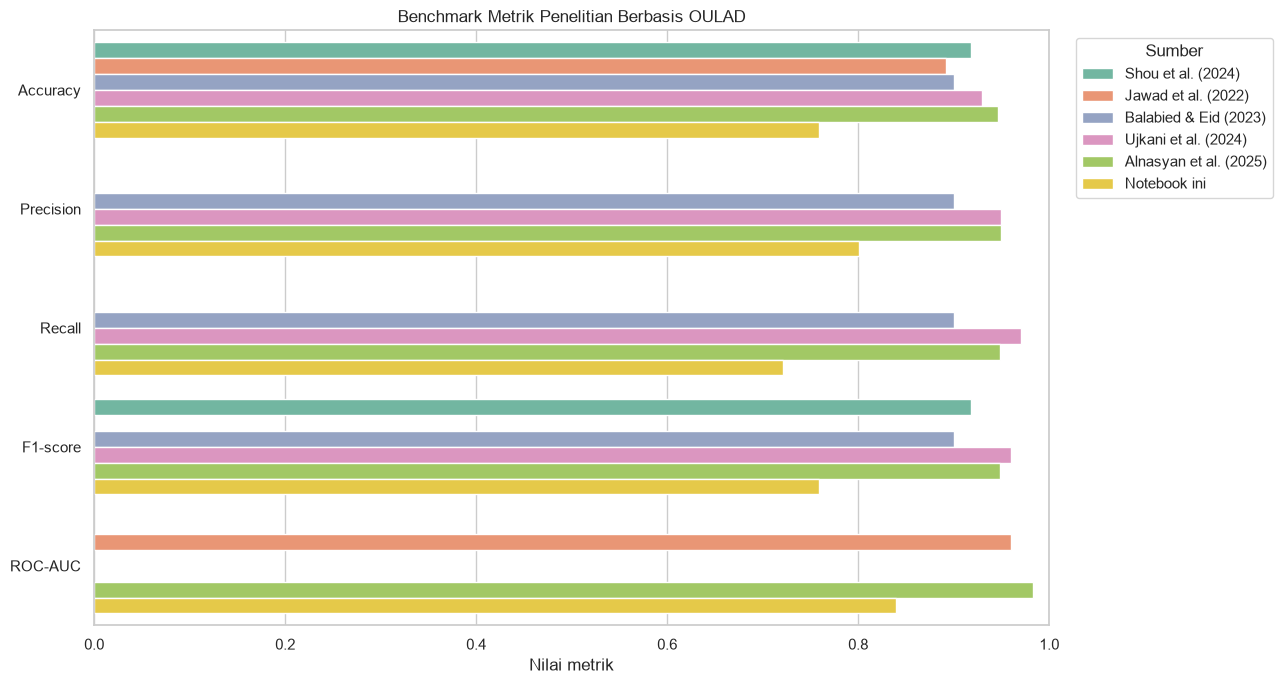

In [11]:
# Benchmark angka dari paper terdahulu dan hasil model terbaik notebook.
benchmark_metrics = pd.DataFrame([
    {
        'Sumber': 'Shou et al. (2024)',
        'Skenario': 'OULAD, 20% course, Pass/Distinction vs Fail/Withdrawn',
        'Model': 'MTAPSP (daily)',
        'Accuracy': 0.9179,
        'Precision': np.nan,
        'Recall': np.nan,
        'F1-score': 0.9180,
        'ROC-AUC': np.nan
    },
    {
        'Sumber': 'Jawad et al. (2022)',
        'Skenario': 'OULAD, 260 hari + SMOTE',
        'Model': 'Random Forest',
        'Accuracy': 0.892,
        'Precision': np.nan,
        'Recall': np.nan,
        'F1-score': np.nan,
        'ROC-AUC': 0.96
    },
    {
        'Sumber': 'Balabied & Eid (2023)',
        'Skenario': 'OULAD, klasifikasi biner',
        'Model': 'Random Forest',
        'Accuracy': 0.90,
        'Precision': 0.90,
        'Recall': 0.90,
        'F1-score': 0.90,
        'ROC-AUC': np.nan
    },
    {
        'Sumber': 'Ujkani et al. (2024)',
        'Skenario': 'OULAD, Fail + Withdrawn sebagai at-risk',
        'Model': 'Custom Neural Network',
        'Accuracy': 0.93,
        'Precision': 0.95,
        'Recall': 0.97,
        'F1-score': 0.96,
        'ROC-AUC': np.nan
    },
    {
        'Sumber': 'Alnasyan et al. (2025)',
        'Skenario': 'OULAD, Pass + Distinction vs Fail + Withdrawn',
        'Model': 'KANFormer',
        'Accuracy': 0.9459,
        'Precision': 0.9495,
        'Recall': 0.9482,
        'F1-score': 0.9481,
        'ROC-AUC': 0.9835
    },
    {
        'Sumber': 'Notebook ini',
        'Skenario': 'OULAD minggu ke-4',
        'Model': best_model_name,
        'Accuracy': test_results.loc[best_model_name, 'accuracy'],
        'Precision': test_results.loc[best_model_name, 'precision_atrisk'],
        'Recall': test_results.loc[best_model_name, 'recall_atrisk'],
        'F1-score': test_results.loc[best_model_name, 'f1_atrisk'],
        'ROC-AUC': test_results.loc[best_model_name, 'roc_auc']
    }
])

display(benchmark_metrics.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}, na_rep='-'))

benchmark_long = benchmark_metrics.melt(
    id_vars=['Sumber', 'Skenario', 'Model'],
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'],
    var_name='Metrik',
    value_name='Nilai'
).dropna()

plt.figure(figsize=(13, 7))
sns.barplot(data=benchmark_long, y='Metrik', x='Nilai', hue='Sumber')
plt.xlim(0, 1)
plt.title('Benchmark Metrik Penelitian Berbasis OULAD')
plt.xlabel('Nilai metrik')
plt.ylabel('')
plt.legend(title='Sumber', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 11. Visualisasi Evaluasi Model

Visualisasi berikut membandingkan metrik, confusion matrix, dan ROC curve. *Confusion matrix* merangkum prediksi benar serta salah untuk setiap kelas, sedangkan ROC curve menunjukkan kemampuan pemisahan kelas pada berbagai threshold keputusan. False negative menunjukkan mahasiswa `AtRisk` yang diprediksi `Successful`.


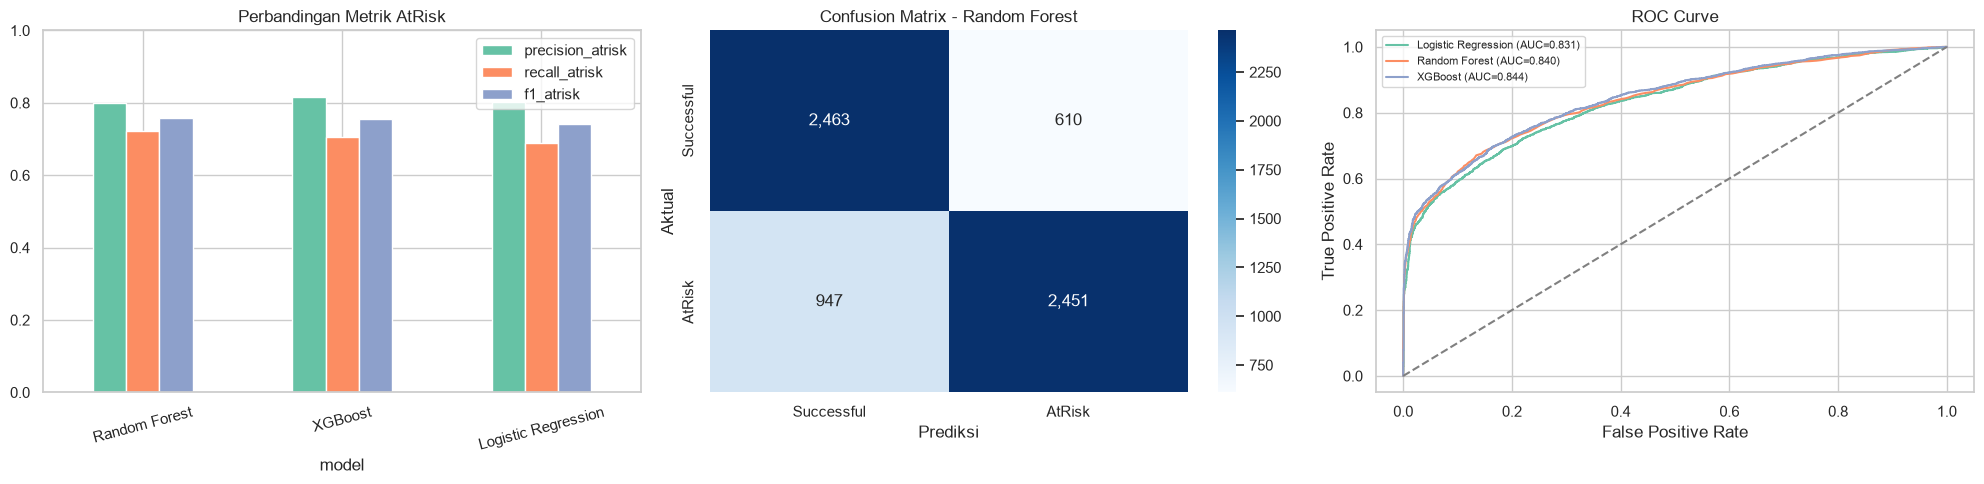

In [12]:
# Siapkan tiga panel visual: perbandingan metrik, confusion matrix, dan ROC curve.
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
test_results[['precision_atrisk', 'recall_atrisk', 'f1_atrisk']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Perbandingan Metrik AtRisk'); axes[0].set_ylim(0, 1); axes[0].tick_params(axis='x', rotation=15)

# Confusion matrix menunjukkan kombinasi prediksi benar dan salah untuk model terbaik.
cm_best = confusion_matrix(y_test, best_pred)
sns.heatmap(cm_best, annot=True, fmt=',d', cmap='Blues', ax=axes[1],
            xticklabels=['Successful', 'AtRisk'], yticklabels=['Successful', 'AtRisk'])
axes[1].set_title(f'Confusion Matrix - {best_model_name}')
axes[1].set_xlabel('Prediksi'); axes[1].set_ylabel('Aktual')

# ROC curve membandingkan kemampuan pemeringkatan risiko dari setiap model.
for name, prob in test_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
axes[2].plot([0, 1], [0, 1], '--', color='gray')
axes[2].set_title('ROC Curve'); axes[2].set_xlabel('False Positive Rate'); axes[2].set_ylabel('True Positive Rate')
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 12. Feature Importance of the Final Model

Feature importance menunjukkan kontribusi setiap feature pada prediksi model. Untuk model pohon, nilai ini berasal dari `feature_importances_`; untuk Logistic Regression, kontribusi dibaca dari nilai absolut coefficient.

**Interpretasi:** feature importance menunjukkan kontribusi prediktif global di dalam model. Analisis hubungan sebab-akibat memerlukan rancangan penelitian kausal. Alasan pada daftar prioritas berasal dari rule-based risk layer dan diterjemahkan menjadi tindak lanjut operasional.

Grafik berikut menampilkan top 15 features dengan kontribusi prediktif terbesar.


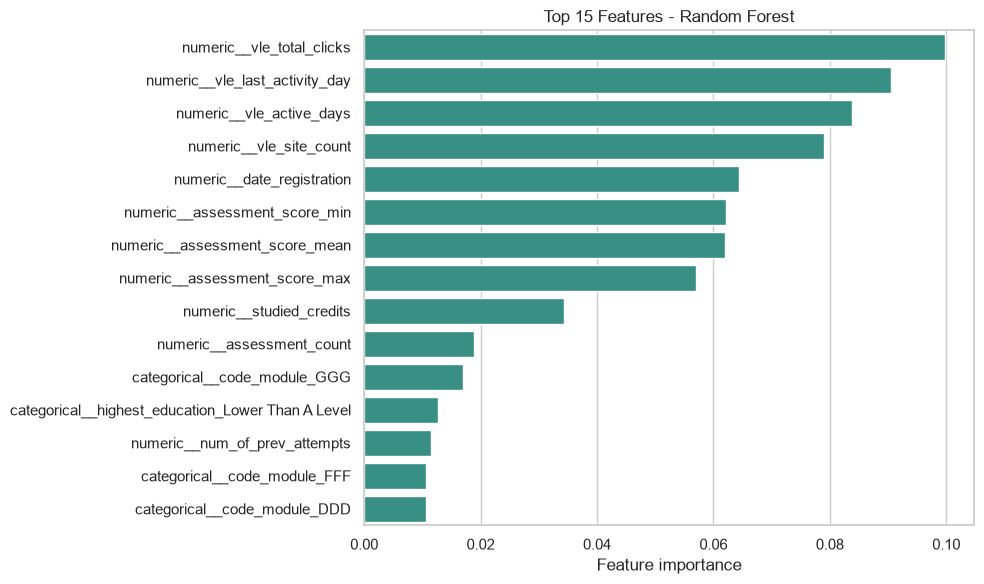

,feature,importance
7,numeric__vle_total_clicks,0.099771
10,numeric__vle_last_activity_day,0.090496
8,numeric__vle_active_days,0.083878
9,numeric__vle_site_count,0.078905
2,numeric__date_registration,0.064367
6,numeric__assessment_score_min,0.062229
4,numeric__assessment_score_mean,0.062033
5,numeric__assessment_score_max,0.056934
1,numeric__studied_credits,0.034319
3,numeric__assessment_count,0.018800


In [13]:
# Ambil nama fitur setelah preprocessing agar importance cocok dengan kolom hasil encoding.
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()
estimator = best_model.named_steps['model']
# Model pohon memakai feature_importances_; Logistic Regression memakai absolut koefisien.
if hasattr(estimator, 'feature_importances_'):
    importance_values = estimator.feature_importances_
    importance_label = 'Feature importance'
else:
    importance_values = np.abs(estimator.coef_[0])
    importance_label = 'Absolute coefficient'

# Urutkan 15 fitur teratas untuk visualisasi interpretasi model.
feature_importance = (pd.DataFrame({'feature': feature_names, 'importance': importance_values})
                      .sort_values('importance', ascending=False).head(15))
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', color='#2A9D8F')
plt.title(f'Top 15 Features - {best_model_name}')
plt.xlabel(importance_label); plt.ylabel(''); plt.tight_layout(); plt.show()
display(feature_importance)

## 13. Knowledge-Based Risk Layer

Knowledge-based risk layer menerjemahkan prediksi model menjadi kategori risiko, skor probabilitas, alasan, dan rekomendasi tindak lanjut. Threshold perilaku dihitung dari kuartil bawah data train, yaitu batas 25% nilai terendah. Probabilitas `AtRisk`, prediksi model, dan jumlah sinyal perilaku membentuk kategori `High`, `Medium`, atau `Low Risk`.

Level risiko menggunakan rule-based grouping, yaitu pengelompokan berdasarkan aturan yang telah ditentukan, untuk decision support setelah model klasifikasi biner menghasilkan prediksi `AtRisk` atau `Successful`.

**Makna probabilitas:** `probability_atrisk` adalah `P(AtRisk)`, yaitu probabilitas kelas positif `AtRisk` yang dihasilkan model melalui `predict_proba(... )[:, 1]`. Prediksi kelas biner berasal dari `predict`. Nilai ini digunakan sebagai probabilitas risiko model untuk prioritisasi. Kalibrasi probabilitas, yaitu penyesuaian agar nilai probabilitas mendekati frekuensi kejadian sebenarnya, dan tuning threshold keputusan menjadi pengembangan berikutnya.

**Aturan:** High = model `AtRisk` dan minimal dua sinyal; Medium = model `AtRisk` atau minimal dua sinyal; selain itu Low.

**Alasan dua sinyal:** minimal dua sinyal perilaku digunakan untuk membuat kategori `High Risk` lebih kuat secara operasional. Kombinasi prediksi model dan beberapa indikator rendah membantu menyusun prioritas intervensi yang lebih terarah.

Kuartil bawah digunakan sebagai baseline berbasis distribusi train. Nilai ini belum menjadi kebijakan final institusi dan perlu divalidasi bersama dosen, tutor, atau pengelola akademik sebelum dipakai untuk intervensi nyata.

Threshold, distribusi level risiko, probabilitas, alasan, dan rekomendasi disajikan pada output berikut.


In [14]:
# Threshold aturan dihitung dari kuartil bawah data train agar tidak mengambil informasi test.
# Nilai threshold ini adalah baseline knowledge rule dan perlu validasi pakar akademik.
RULE_COLS = ['assessment_score_mean', 'assessment_count', 'vle_total_clicks', 'vle_active_days']
thresholds = X_train[RULE_COLS].quantile(0.25).to_dict()

# Fungsi ini menambahkan prediksi ML, sinyal aturan, level risiko, dan rekomendasi.
def add_knowledge_layer(frame, ml_pred, ml_prob, thresholds):
    result = frame.copy()
    result['predicted_atrisk'] = np.asarray(ml_pred).astype(int)
    result['probability_atrisk'] = np.asarray(ml_prob)
    # Setiap kondisi bernilai True jika perilaku mahasiswa berada di bawah threshold train.
    signal_map = {
        'Skor assessment rendah': result['assessment_score_mean'] <= thresholds['assessment_score_mean'],
        'Partisipasi assessment rendah': result['assessment_count'] <= thresholds['assessment_count'],
        'Total klik VLE rendah': result['vle_total_clicks'] <= thresholds['vle_total_clicks'],
        'Hari aktif VLE rendah': result['vle_active_days'] <= thresholds['vle_active_days']
    }
    result['risk_signal_count'] = sum(condition.astype(int) for condition in signal_map.values())
    result['risk_reasons'] = [
        '; '.join(name for name, condition in signal_map.items() if bool(condition.iloc[i])) or 'Tidak ada sinyal aturan'
        for i in range(len(result))
    ]
    # Aturan level risiko menggabungkan prediksi model dan jumlah sinyal perilaku.
    # Ini bukan clustering; ini grouping operasional dari hasil klasifikasi dan indikator awal.
    high = (result['predicted_atrisk'] == 1) & (result['risk_signal_count'] >= 2)
    medium = (result['predicted_atrisk'] == 1) | (result['risk_signal_count'] >= 2)
    result['knowledge_risk_level'] = np.select([high, medium], ['High Risk', 'Medium Risk'], default='Low Risk')

    # Rekomendasi dibuat dari jenis sinyal yang muncul pada tiap mahasiswa.
    def recommendation(row):
        reasons = row['risk_reasons']
        actions = []
        if 'VLE' in reasons: actions.append('pengingat dan monitoring akses VLE')
        if 'assessment' in reasons: actions.append('pendampingan assessment')
        if row['risk_signal_count'] >= 3: actions.append('konseling atau tindak lanjut dosen wali')
        return '; '.join(actions) if actions else 'monitoring rutin'
    result['recommended_action'] = result.apply(recommendation, axis=1)
    return result

# Terapkan knowledge layer pada data test agar hasilnya sejalan dengan evaluasi hold-out.
test_output = dataset.iloc[test_idx].copy().reset_index(drop=True)
test_output = add_knowledge_layer(test_output, best_pred, best_prob, thresholds)
print('Threshold aturan dari kuartil bawah data train:')
display(pd.Series(thresholds, name='threshold').to_frame().round(2))
display(test_output['knowledge_risk_level'].value_counts().to_frame('jumlah'))
display(test_output[['id_student', 'code_module', 'code_presentation', 'predicted_atrisk',
                     'probability_atrisk', 'risk_signal_count', 'knowledge_risk_level',
                     'risk_reasons', 'recommended_action']].head())

Threshold aturan dari kuartil bawah data train:


,threshold
assessment_score_mean,0.0
assessment_count,0.0
vle_total_clicks,47.0
vle_active_days,4.0


,jumlah
knowledge_risk_level,
Low Risk,2676
Medium Risk,1979
High Risk,1816


,id_student,code_module,code_presentation,predicted_atrisk,probability_atrisk,risk_signal_count,knowledge_risk_level,risk_reasons,recommended_action
0,11391,AAA,2013J,0,0.392,0,Low Risk,Tidak ada sinyal aturan,monitoring rutin
1,38053,AAA,2013J,0,0.188,0,Low Risk,Tidak ada sinyal aturan,monitoring rutin
2,52130,AAA,2013J,0,0.148,0,Low Risk,Tidak ada sinyal aturan,monitoring rutin
3,63400,AAA,2013J,0,0.164,0,Low Risk,Tidak ada sinyal aturan,monitoring rutin
4,74372,AAA,2013J,1,0.600,1,Medium Risk,Total klik VLE rendah,pengingat dan monitoring akses VLE


## 14. Evaluasi Alarm Intervensi

`High Risk` dan `Medium Risk` dipetakan menjadi alarm `AtRisk`, lalu metriknya dibandingkan dengan model machine learning final.

Penggabungan `High Risk` dan `Medium Risk` sebagai `AtRisk` sengaja diarahkan untuk meningkatkan cakupan deteksi. Konsekuensinya, precision, yaitu proporsi alarm yang benar-benar `AtRisk`, dapat turun dan antrean intervensi menjadi lebih besar. Hubungan saling tarik ini disebut trade-off, sehingga hasil tetap perlu diverifikasi manusia.

Tabel dan confusion matrix berikut menunjukkan perubahan recall dan precision setelah aturan diterapkan.


In [15]:
# Untuk evaluasi biner, High Risk dan Medium Risk diperlakukan sebagai AtRisk.
# Pilihan ini menekankan recall, dengan konsekuensi precision dan beban intervensi perlu dipantau.
knowledge_pred = test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']).astype(int)
# Bandingkan metrik model ML murni dengan sistem setelah ditambah knowledge layer.
comparison = pd.DataFrame([
    {'sistem': f'Model ML ({best_model_name})', **calculate_metrics(y_test, best_pred, best_prob)},
    {'sistem': 'Model + Knowledge Layer',
     'accuracy': accuracy_score(y_test, knowledge_pred),
     'precision_atrisk': precision_score(y_test, knowledge_pred, zero_division=0),
     'recall_atrisk': recall_score(y_test, knowledge_pred, zero_division=0),
     'f1_atrisk': f1_score(y_test, knowledge_pred, zero_division=0),
     'roc_auc': np.nan}
]).set_index('sistem')
display(comparison.style.format('{:.4f}', na_rep='-'))
# Confusion matrix tambahan menunjukkan perubahan setelah aturan diterapkan.
print('Confusion matrix alarm intervensi:')
display(pd.DataFrame(confusion_matrix(y_test, knowledge_pred),
                     index=['Aktual Successful', 'Aktual AtRisk'],
                     columns=['Prediksi Successful', 'Prediksi AtRisk']))

,accuracy,precision_atrisk,recall_atrisk,f1_atrisk,roc_auc
sistem,,,,,
Model ML (Random Forest),0.7594,0.8007,0.7213,0.7589,0.8396
Model + Knowledge Layer,0.7146,0.7043,0.7866,0.7432,-


Confusion matrix alarm intervensi:


,Prediksi Successful,Prediksi AtRisk
Aktual Successful,1951,1122
Aktual AtRisk,725,2673


## 15. Dashboard Monitoring Akademik

Dashboard menyatukan indikator model dan risiko untuk monitoring akademik. KPI (*Key Performance Indicator*) merangkum kondisi utama, seperti jumlah mahasiswa dalam antrean prioritas. Visualisasi mencakup distribusi level, risiko per module-presentation, probabilitas, sinyal dominan, perilaku per level, dan confusion matrix.


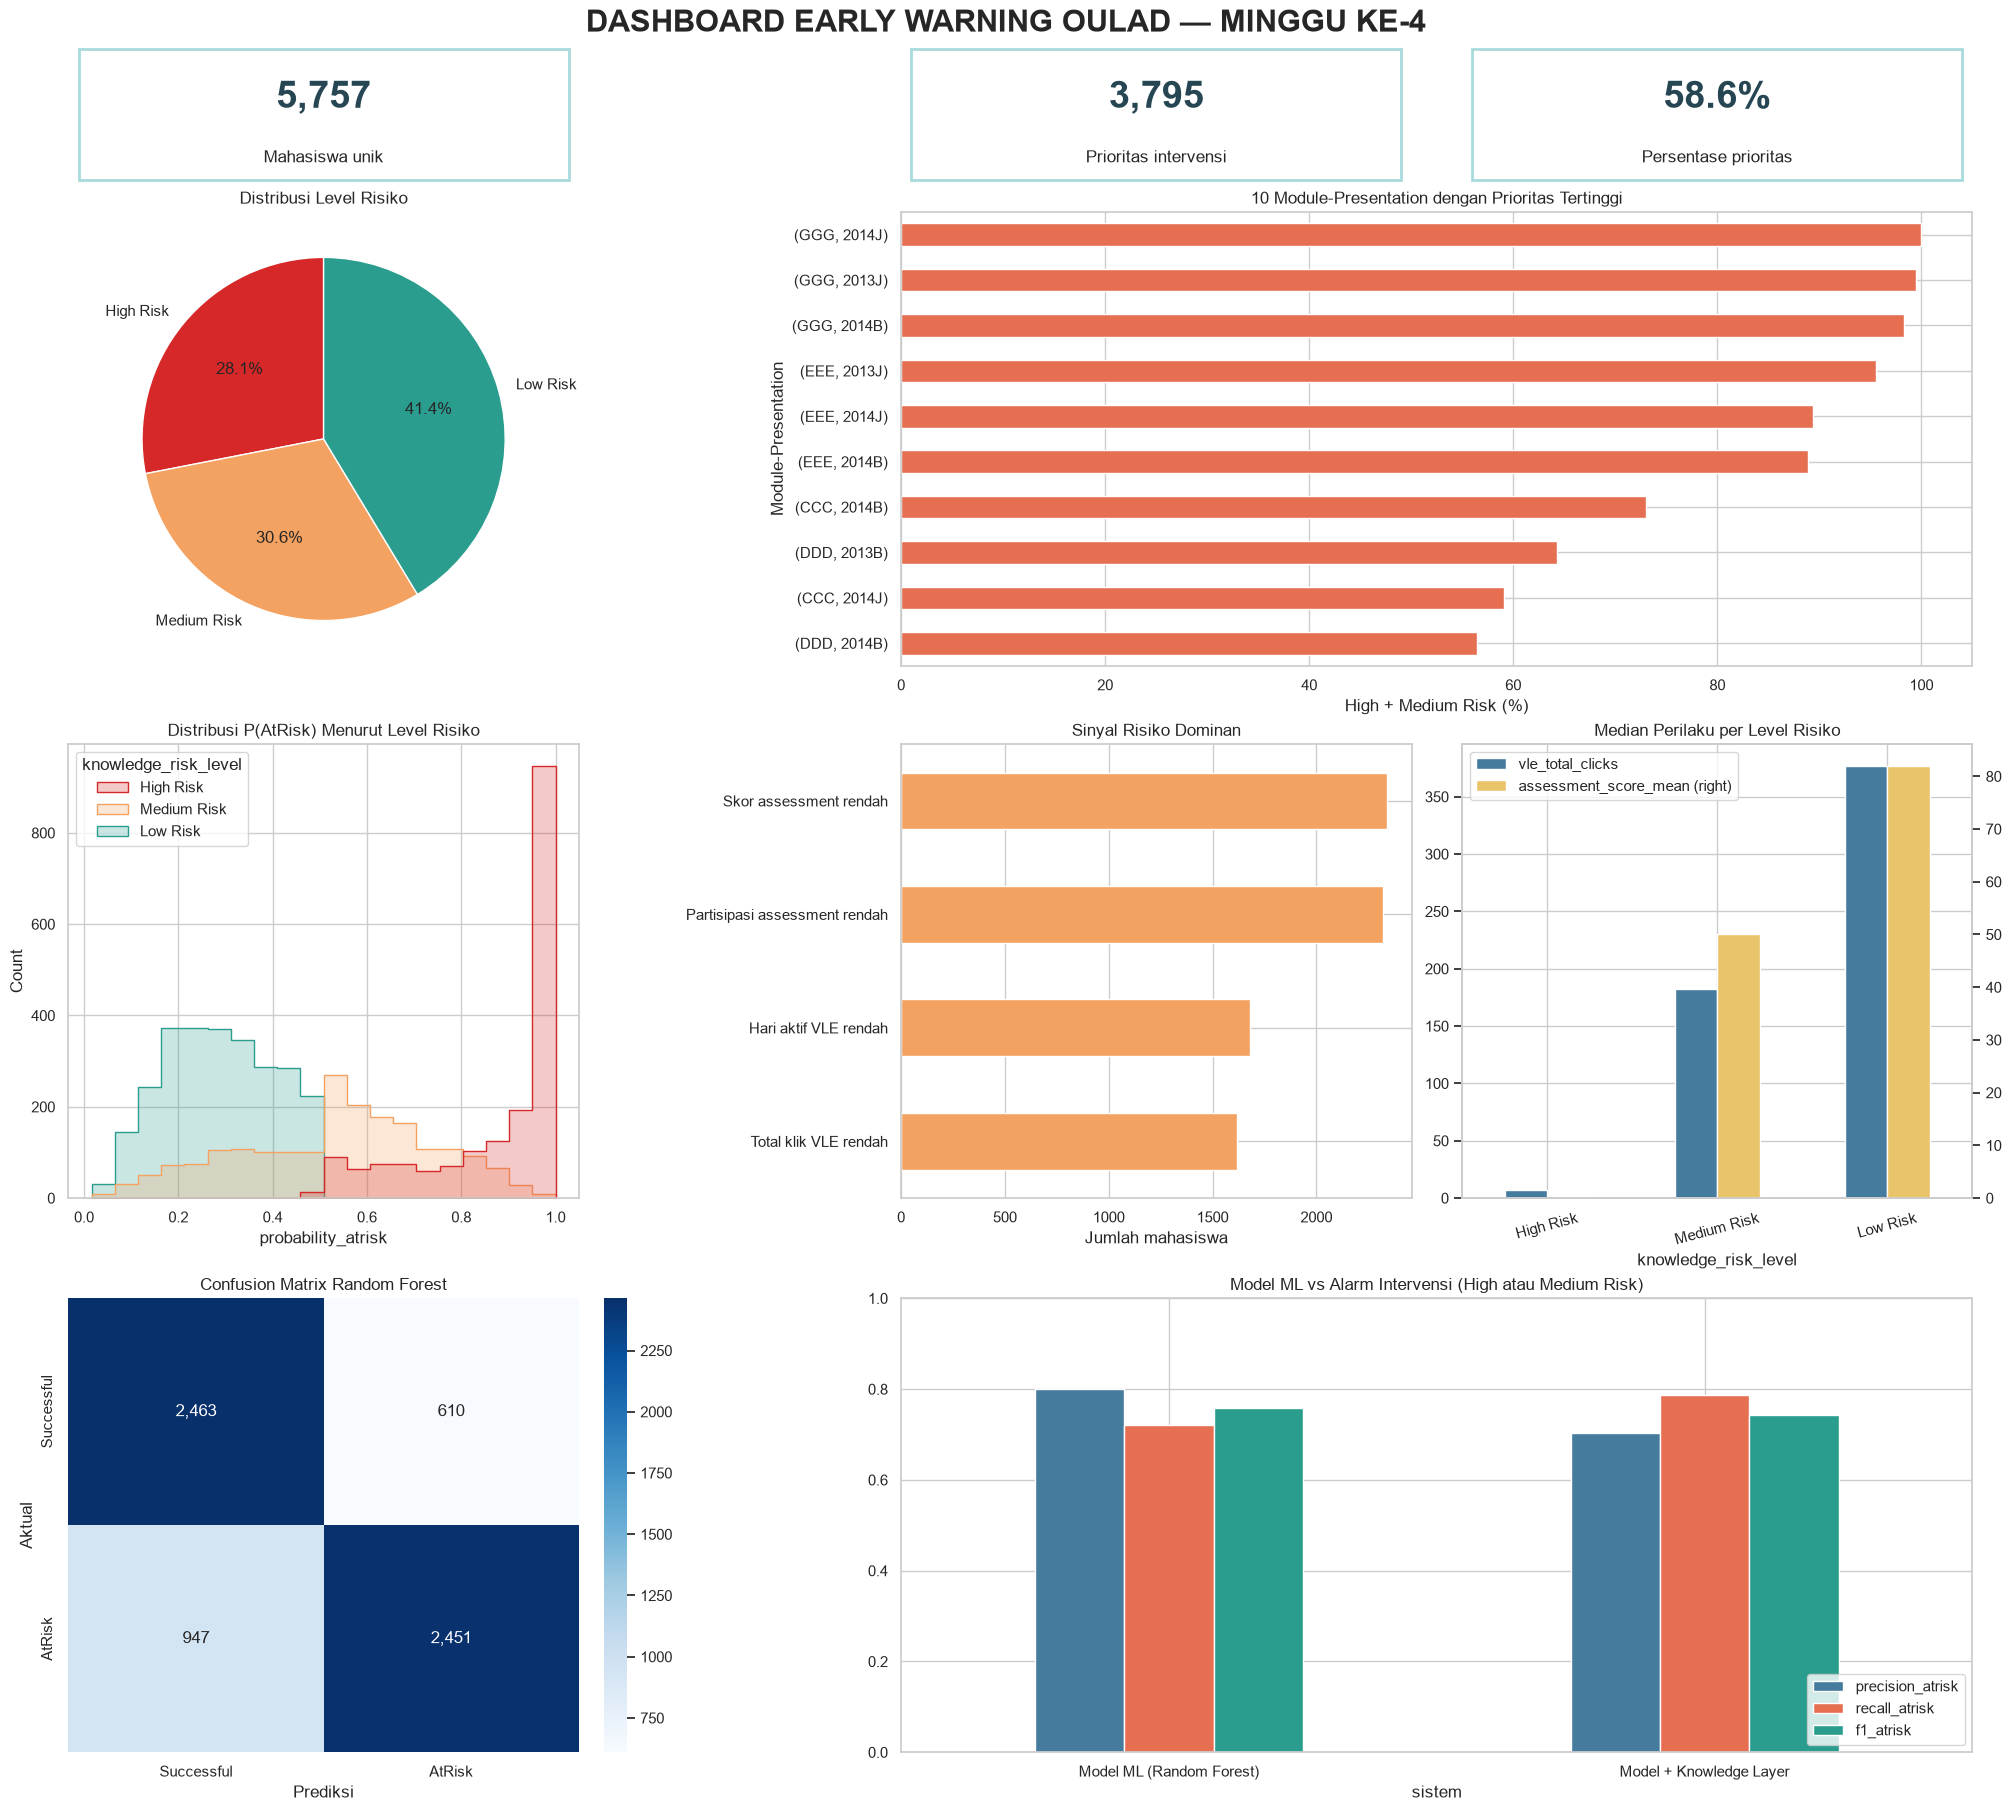

In [16]:
# Tetapkan urutan dan warna level risiko agar semua grafik konsisten.
level_order = ['High Risk', 'Medium Risk', 'Low Risk']
level_colors = {'High Risk': '#D62828', 'Medium Risk': '#F4A261', 'Low Risk': '#2A9D8F'}
level_counts = test_output['knowledge_risk_level'].value_counts().reindex(level_order, fill_value=0)
# Hitung persentase High/Medium Risk per module-presentation.
module_risk = (test_output.assign(is_priority=test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']))
               .groupby(['code_module', 'code_presentation'])['is_priority'].mean()
               .sort_values(ascending=False).head(10).mul(100))
# Pecah alasan risiko menjadi indikator agar sinyal dominan bisa dihitung.
all_signals = (test_output['risk_reasons'].str.get_dummies(sep='; ')
               .drop(columns=['Tidak ada sinyal aturan'], errors='ignore').sum().sort_values(ascending=False))
behavior_level = test_output.groupby('knowledge_risk_level')[
    ['vle_total_clicks', 'assessment_score_mean']].median().reindex(level_order)

# KPI dashboard merangkum jumlah mahasiswa dan antrean prioritas.
total_students = test_output['id_student'].nunique()
priority_count = test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk']).sum()
priority_pct = 100 * priority_count / len(test_output)

# Susun dashboard statis dari KPI, distribusi risiko, modul prioritas, dan metrik evaluasi.
fig = plt.figure(figsize=(20, 18), constrained_layout=True)
grid = fig.add_gridspec(4, 3, height_ratios=[0.45, 1.5, 1.5, 1.5])
fig.suptitle('DASHBOARD EARLY WARNING OULAD — MINGGU KE-4', fontsize=22, fontweight='bold')

kpis = [(f'{total_students:,}', 'Mahasiswa unik'), (f'{priority_count:,}', 'Prioritas intervensi'),
        (f'{priority_pct:.1f}%', 'Persentase prioritas')]
for i, (value, label) in enumerate(kpis):
    ax = fig.add_subplot(grid[0, i]); ax.axis('off')
    ax.text(0.5, 0.62, value, ha='center', va='center', fontsize=27, fontweight='bold', color='#264653')
    ax.text(0.5, 0.18, label, ha='center', va='center', fontsize=12)
    ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, fill=False, edgecolor='#A8DADC', linewidth=2))

# Panel risiko: distribusi level dan module-presentation prioritas.
ax1 = fig.add_subplot(grid[1, 0])
ax1.pie(level_counts, labels=level_counts.index, autopct='%1.1f%%', startangle=90,
        colors=[level_colors[x] for x in level_counts.index])
ax1.set_title('Distribusi Level Risiko')

ax2 = fig.add_subplot(grid[1, 1:])
module_risk.sort_values().plot(kind='barh', ax=ax2, color='#E76F51')
ax2.set_title('10 Module-Presentation dengan Prioritas Tertinggi')
ax2.set_xlabel('High + Medium Risk (%)'); ax2.set_ylabel('Module-Presentation')

# Panel perilaku: probabilitas, sinyal dominan, dan median perilaku per level.
ax3 = fig.add_subplot(grid[2, 0])
sns.histplot(data=test_output, x='probability_atrisk', hue='knowledge_risk_level',
             hue_order=level_order, palette=level_colors, bins=20, ax=ax3, element='step')
ax3.set_title('Distribusi P(AtRisk) Menurut Level Risiko')

ax4 = fig.add_subplot(grid[2, 1])
all_signals.sort_values().plot(kind='barh', ax=ax4, color='#F4A261')
ax4.set_title('Sinyal Risiko Dominan'); ax4.set_xlabel('Jumlah mahasiswa')

ax5 = fig.add_subplot(grid[2, 2])
behavior_level.plot(kind='bar', ax=ax5, secondary_y='assessment_score_mean', color=['#457B9D', '#E9C46A'])
ax5.set_title('Median Perilaku per Level Risiko'); ax5.tick_params(axis='x', rotation=15)

# Panel evaluasi: confusion matrix dan perbandingan model dengan knowledge layer.
ax6 = fig.add_subplot(grid[3, 0])
sns.heatmap(cm_best, annot=True, fmt=',d', cmap='Blues', ax=ax6,
            xticklabels=['Successful', 'AtRisk'], yticklabels=['Successful', 'AtRisk'])
ax6.set_title(f'Confusion Matrix {best_model_name}'); ax6.set_xlabel('Prediksi'); ax6.set_ylabel('Aktual')

ax7 = fig.add_subplot(grid[3, 1:])
metric_plot = comparison[['precision_atrisk', 'recall_atrisk', 'f1_atrisk']]
metric_plot.plot(kind='bar', ax=ax7, color=['#457B9D', '#E76F51', '#2A9D8F'])
ax7.set_title('Model ML vs Alarm Intervensi (High atau Medium Risk)'); ax7.set_ylim(0, 1); ax7.tick_params(axis='x', rotation=0)
ax7.legend(loc='lower right')
plt.show()

## 16. Prioritas Intervensi dan Temuan Utama

Mahasiswa pada level High Risk dan Medium Risk diurutkan berdasarkan `probability_atrisk` serta jumlah sinyal. Urutan ini membentuk antrean intervensi dan menghasilkan temuan otomatis tentang module-presentation serta sinyal risiko dominan. Tabel berikut menampilkan 20 prioritas teratas, probabilitas, alasan risiko, dan rekomendasi tindakan.


In [17]:
# Daftar prioritas hanya mengambil mahasiswa dengan High Risk atau Medium Risk.
priority_table = (test_output[test_output['knowledge_risk_level'].isin(['High Risk', 'Medium Risk'])]
    .sort_values(['knowledge_risk_level', 'probability_atrisk', 'risk_signal_count'],
                 ascending=[True, False, False])
    [['id_student', 'code_module', 'code_presentation', 'probability_atrisk',
      'knowledge_risk_level', 'risk_signal_count', 'risk_reasons', 'recommended_action']])

# Ambil konteks dan sinyal paling menonjol untuk insight BI otomatis.
top_context = module_risk.index[0]
top_signal = all_signals.index[0]
print('TEMUAN UTAMA UNTUK INTERVENSI AKADEMIK')
print(f'1. Prioritas tertinggi: module {top_context[0]} presentation {top_context[1]} '
      f'dengan {module_risk.iloc[0]:.1f}% kasus High/Medium Risk.')
print(f'2. Sinyal risiko paling dominan: {top_signal} ({int(all_signals.iloc[0]):,} kasus).')
print(f'3. Total antrean intervensi: {len(priority_table):,} student-module-presentation.')
print('4. Probabilitas dan alasan risiko membentuk urutan tindak lanjut.')
print('5. Daftar prioritas mendukung verifikasi dan intervensi akademik.')

# Tampilkan probabilitas menggunakan representasi raw float.
raw_probability = lambda value: repr(float(value))
display(priority_table.head(20).style.format({'probability_atrisk': raw_probability}))

TEMUAN UTAMA UNTUK INTERVENSI AKADEMIK
1. Prioritas tertinggi: module GGG presentation 2014J dengan 100.0% kasus High/Medium Risk.
2. Sinyal risiko paling dominan: Skor assessment rendah (2,341 kasus).
3. Total antrean intervensi: 3,795 student-module-presentation.
4. Probabilitas dan alasan risiko membentuk urutan tindak lanjut.
5. Daftar prioritas mendukung verifikasi dan intervensi akademik.


,id_student,code_module,code_presentation,probability_atrisk,knowledge_risk_level,risk_signal_count,risk_reasons,recommended_action
116,323805,AAA,2014J,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
170,87604,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
171,88580,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
175,143854,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
201,323914,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
209,353918,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
211,357038,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
236,423317,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
267,488929,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali
290,505123,BBB,2013B,1.0,High Risk,4,Skor assessment rendah; Partisipasi assessment rendah; Total klik VLE rendah; Hari aktif VLE rendah,pengingat dan monitoring akses VLE; pendampingan assessment; konseling atau tindak lanjut dosen wali


## 17. Ekspor Artefak Analisis

Metrik model, evaluasi knowledge layer, dan daftar prioritas disimpan sebagai CSV untuk reproduksibilitas dan analisis lanjutan.


In [18]:
# Folder output dibuat di runtime Colab.
OUTPUT_DIR = RUNTIME_DIR / 'oulad_dvbi_output'
OUTPUT_DIR.mkdir(exist_ok=True)
# Simpan metrik model, evaluasi knowledge layer, dan daftar prioritas ke CSV.
test_results.reset_index().to_csv(OUTPUT_DIR / 'model_evaluation.csv', index=False)
comparison.reset_index().to_csv(OUTPUT_DIR / 'knowledge_layer_evaluation.csv', index=False)
priority_table.to_csv(OUTPUT_DIR / 'intervention_priority.csv', index=False)
# Tampilkan daftar artefak untuk reproduksibilitas analisis.
exported_files = pd.DataFrame({'Artefak': sorted(p.name for p in OUTPUT_DIR.iterdir())})
print('Artefak analisis yang diekspor')
display(exported_files)

Artefak analisis yang diekspor


,Artefak
0,intervention_priority.csv
1,knowledge_layer_evaluation.csv
2,model_evaluation.csv


## 18. Kesimpulan dan keterbatasan

**Kesimpulan:** penelitian ini membandingkan Logistic Regression, Random Forest, dan XGBoost menggunakan supervised binary classification untuk mengenali risiko `Withdrawn` atau `Fail` berdasarkan informasi sampai minggu keempat. Random Forest dipilih karena memperoleh mean recall `AtRisk` tertinggi pada cross-validation.

Pada hold-out test, Random Forest menghasilkan recall `AtRisk` 0,7213 dan precision `AtRisk` 0,8007. Knowledge-based risk layer kemudian menggabungkan prediksi model dengan sinyal assessment dan VLE untuk membentuk level `High Risk`, `Medium Risk`, dan `Low Risk` beserta alasan dan rekomendasi. Dashboard menyajikan hasil tersebut sebagai indikator monitoring dan prioritas intervensi.

**Keterbatasan:**
- Target dibentuk dari hasil akhir, dengan predictors yang tersedia sampai hari ke-28.
- Level risiko dan threshold kuartil merupakan aturan operasional berbasis data; feature importance menunjukkan kontribusi prediktif dalam model.
- Peningkatan recall berkaitan dengan perubahan precision dan jumlah kasus dalam antrean intervensi.
- Probability calibration, hyperparameter tuning, optimasi classification threshold, dan evaluasi fairness menjadi ruang pengembangan berikutnya.
- OULAD merepresentasikan konteks Open University di Inggris; penerapan pada institusi lain dilanjutkan melalui validasi dengan data dan proses akademik setempat.

